In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def load_data(file_path):
    """
    Loads data from a CSV file.
    """
    return pd.read_csv(file_path)


In [17]:
data = load_data("adult.csv")
plots_dir="../../output/plots/adult/"

In [19]:
data = load_data("compas-scores-two-years.csv")
data.shape

(7214, 53)

In [20]:
data.isna().sum()

id                            0
name                          0
first                         0
last                          0
compas_screening_date         0
sex                           0
dob                           0
age                           0
age_cat                       0
race                          0
juv_fel_count                 0
decile_score                  0
juv_misd_count                0
juv_other_count               0
priors_count                  0
days_b_screening_arrest     307
c_jail_in                   307
c_jail_out                  307
c_case_number                22
c_offense_date             1159
c_arrest_date              6077
c_days_from_compas           22
c_charge_degree               0
c_charge_desc                29
is_recid                      0
r_case_number              3743
r_charge_degree            3743
r_days_from_arrest         4898
r_offense_date             3743
r_charge_desc              3801
r_jail_in                  4898
r_jail_o

In [21]:
data_curr = data[['sex', 'race', 'age', 'c_charge_degree', 'juv_fel_count', 'juv_misd_count', 'priors_count', 'is_recid', 'decile_score']].copy()
data_curr.isna().sum()

sex                0
race               0
age                0
c_charge_degree    0
juv_fel_count      0
juv_misd_count     0
priors_count       0
is_recid           0
decile_score       0
dtype: int64

In [16]:
data.shape

(7214, 53)

In [7]:
plots_dir="../../output/plots/compas/"
data_curr = data[['sex', 'race', 'age', 'c_charge_degree', 'juv_fel_count', 'juv_misd_count', 'priors_count', 'is_recid', 'decile_score']].copy()
data_curr['risk'] = data_curr['decile_score'].apply(lambda x: 'Low Risk' if x < 6 else 'High Risk')
data_curr = data_curr[data_curr['race'].isin(['African-American', 'Caucasian'])]
data_curr.shape

(6150, 10)

In [ ]:
data.shape

(6150, 10)

In [11]:
data_curr.columns

Index(['sex', 'race', 'age', 'c_charge_degree', 'juv_fel_count',
       'juv_misd_count', 'priors_count', 'is_recid', 'decile_score', 'risk'],
      dtype='object')

In [5]:
# Adult
data['education'].value_counts()

education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

In [182]:
# COMPAS
data['race'].value_counts()

race
African-American    3696
Caucasian           2454
Hispanic             637
Other                377
Asian                 32
Native American       18
Name: count, dtype: int64

In [185]:
# COMPAS
data['risk'].value_counts()

risk
1.0    4578
0.0    2636
Name: count, dtype: int64

In [ ]:
#count nan values
data.isna().sum()

sex                0
race               0
age                0
c_charge_degree    0
juv_fel_count      0
juv_misd_count     0
priors_count       0
is_recid           0
decile_score       0
risk               0
dtype: int64

In [143]:
data.nunique()

id                         7214
name                       7158
first                      2800
last                       3950
compas_screening_date       690
sex                           2
dob                        5452
age                          65
age_cat                       3
race                          6
juv_fel_count                11
decile_score                 10
juv_misd_count               10
juv_other_count              10
priors_count                 37
days_b_screening_arrest     423
c_jail_in                  6907
c_jail_out                 6880
c_case_number              7192
c_offense_date              927
c_arrest_date               580
c_days_from_compas          499
c_charge_degree               2
c_charge_desc               437
is_recid                      2
r_case_number              3471
r_charge_degree              10
r_days_from_arrest          201
r_offense_date             1075
r_charge_desc               340
r_jail_in                   972
r_jail_o

In [142]:
num_question_marks = (data == '?').sum().sum()
print(f"Number of '?' values in the dataframe: {num_question_marks}")

Number of '?' values in the dataframe: 0


In [27]:
num_rows_with_question_marks = data.isin(['?']).any(axis=1).sum()
print(f"Number of rows with at least one '?' value: {num_rows_with_question_marks}")
print(f"it is the {num_rows_with_question_marks / data.shape[0] * 100:.2f}% of the data")

Number of rows with at least one '?' value: 2399
it is the 7.37% of the data


In [188]:
data.isnull().sum()

sex                0
race               0
age                0
c_charge_degree    0
juv_fel_count      0
juv_misd_count     0
priors_count       0
is_recid           0
decile_score       0
risk               0
dtype: int64

In [42]:
data.replace('?', np.nan, inplace=True)
data.shape

(32561, 15)

In [151]:
data.dropna(inplace=True)
data.shape

(0, 53)

In [ ]:
# data['native.country'].value_counts()

native.country
United-States                 27504
Mexico                          610
Philippines                     188
Germany                         128
Puerto-Rico                     109
Canada                          107
El-Salvador                     100
India                           100
Cuba                             92
England                          86
Jamaica                          80
South                            71
Italy                            68
China                            68
Dominican-Republic               67
Vietnam                          64
Guatemala                        63
Japan                            59
Poland                           56
Columbia                         56
Taiwan                           42
Haiti                            42
Iran                             42
Portugal                         34
Nicaragua                        33
Peru                             30
Greece                           29
Ecuador      

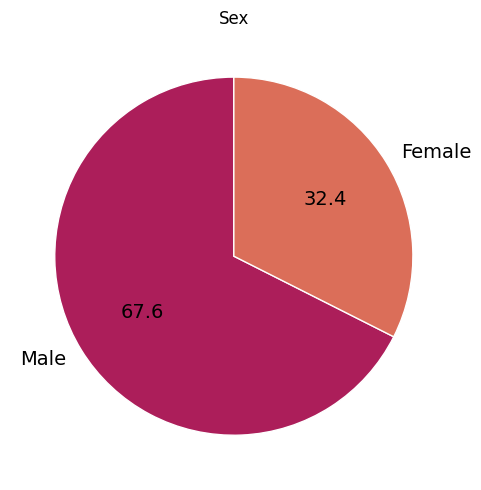

In [ ]:
# plt.figure(figsize=(5, 5))  # Adjust figure size to reduce excess space
# filepath = plots_dir[0]+'adult/sex_distribution.png'
# sex_distribution = data['sex'].value_counts()

# sex_distribution.plot(
#     kind='pie', 
#     autopct='%1.1f', 
#     textprops={'fontsize': 14},
#     startangle=90, 
#     colors=['#ac1e5a','#db6e59'],
#     wedgeprops={'edgecolor': 'white'}  # Optional: Add white borders for better visibility
# )

# plt.ylabel('')
# plt.title('Sex')

# # Adjust layout to reduce white space
# plt.tight_layout()
# plt.show()

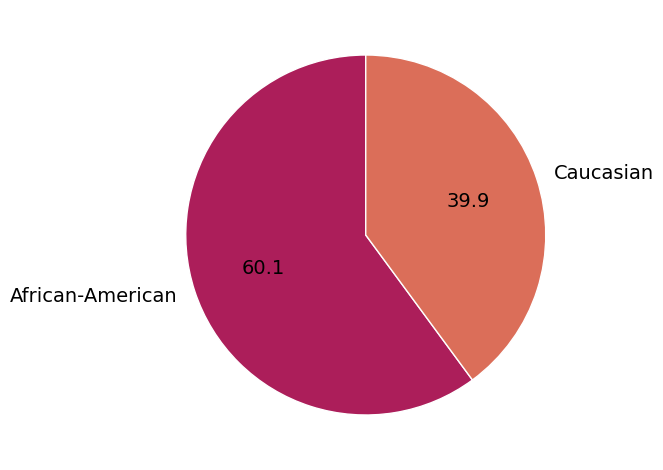

In [ ]:
filepath = plots_dir[0]+'/race_distribution.png'
race_distribution = data['race'].value_counts()

race_distribution.plot(
    kind='pie', 
    autopct='%1.1f', 
    textprops={'fontsize': 14},
    startangle=90, 
    colors=['#ac1e5a','#db6e59'],
    wedgeprops={'edgecolor': 'white'}  # Optional: Add white borders for better visibility
)

plt.ylabel('')
plt.title('')

# Adjust layout to reduce white space
plt.tight_layout()

# Save the plot with minimal whitespace
plt.show()


In [ ]:
plt.figure(figsize=(5, 5))  # Adjust figure size to reduce excess space
filepath = plots_dir[0]+'/sex_distribution.png'
sex_distribution = data['sex'].value_counts()

sex_distribution.plot(
    kind='pie', 
    autopct='%1.1f', 
    textprops={'fontsize': 14},
    startangle=90, 
    colors=['#ac1e5a','#db6e59'],
    wedgeprops={'edgecolor': 'white'}  # Optional: Add white borders for better visibility
)

plt.ylabel('')
plt.title('')

# Adjust layout to reduce white space
plt.tight_layout()

# Save the plot with minimal whitespace
plt.savefig(filepath, bbox_inches='tight', pad_inches=0.1)
plt.close()


In [ ]:
plt.figure(figsize=(5, 5))  # Adjust figure size to remove excess space
filepath = plots_dir[0]+'/income_distribution.png'

income_distribution = data['income'].value_counts()

income_distribution.plot(
    kind='pie', 
    autopct='%1.1f', 
    textprops={'fontsize': 14},
    startangle=90, 
    colors=['#ac1e5a','#db6e59'],
    wedgeprops={'edgecolor': 'white'}  # Optional: Add white borders for better visibility
)

plt.ylabel('')
plt.title('')

# Adjust layout to reduce white space
plt.tight_layout()

# Save the plot with minimal whitespace
plt.savefig(filepath, bbox_inches='tight', pad_inches=0.1)
plt.close()

In [199]:
plt.figure(figsize=(5, 5)) 
filepath = '../../output/plots/compas/race_distribution.png'
race_distribution = data['race'].value_counts()

# Modify labels to break "African-American" into two lines
labels = ['African-\nAmerican' if lbl == 'African-American' else lbl for lbl in race_distribution.index]

race_distribution.plot(
    kind='pie', 
    autopct='%1.1f', 
    labels=labels,  # Set modified labels
    textprops={'fontsize': 14},
    startangle=90, 
    colors=['#ac1e5a','#db6e59'],
    wedgeprops={'edgecolor': 'white'}  # Optional: Add white borders for better visibility
)

plt.ylabel('')
plt.title('')
plt.tight_layout()

# Save the plot with minimal whitespace
plt.savefig(filepath, bbox_inches='tight', pad_inches=0.1)
plt.close()


In [202]:
plt.figure(figsize=(5, 5)) 
filepath = '../../output/plots/compas/risk_distribution.png'
risk_distribution = data['risk'].value_counts()

risk_distribution.plot(
    kind='pie', 
    autopct='%1.1f', 
    textprops={'fontsize': 15},
    startangle=90, 
    colors=['#ac1e5a','#db6e59'],
    wedgeprops={'edgecolor': 'white'}  # Optional: Add white borders for better visibility
)
print(filepath)
plt.ylabel('')
plt.title('')

# Adjust layout to reduce white space
plt.tight_layout()

# Save the plot with minimal whitespace
plt.savefig(filepath, bbox_inches='tight', pad_inches=0.1)
plt.close()

../../output/plots/compas/risk_distribution.png
